### Astrostatistics lecture 6

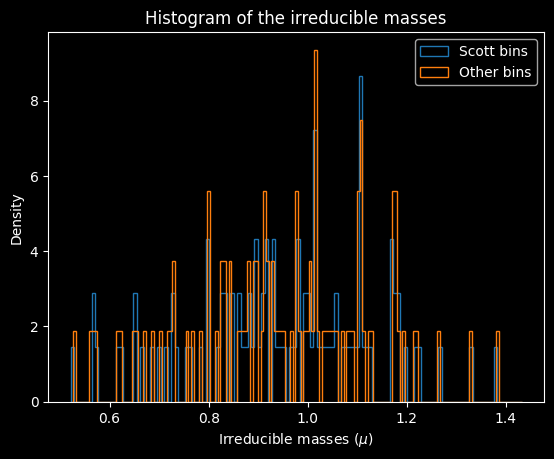

In [44]:
import numpy as np 
import math
import matplotlib.pyplot as plt 
from sklearn.neighbors import KernelDensity
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

def irriducibe (mass, spin): #function to get the irriducible mass given Mass and spin of a BH
    irr = mass*math.sqrt((1+math.sqrt(1-spin**2))/2)
    return irr

#first define stuff
sigma = 0.2
mu = 1
chi = np.random.uniform(0,1,100)
Og_mass = np.random.normal(mu, sigma, 100)
Irr_mass = []
f = []
for i in range(100):   #find the Irriducible mass and the fraction
    Irr_mass.append(irriducibe(Og_mass[i], chi[i]))
    f.append(Irr_mass[i]/Og_mass[i])

bin_scott = 3.5*sigma/(len(Og_mass**(1/3))) #selected bin width using Scott rule 
bin_other = 2.7*sigma/(len(Og_mass**(1/3)))
binned_1 = np.append(np.arange(start=Og_mass.min(), stop=Og_mass.max(), step=bin_scott) , Og_mass.max()) #fill put the bins
binned_2 = np.append(np.arange(start=Og_mass.min(), stop=Og_mass.max(), step=bin_other) , Og_mass.max())

plt.hist(Irr_mass, bins=binned_1, density=True, histtype='step', label=r'Scott bins') #plot the Irriducible mass with the selected bin width
plt.hist(Irr_mass, bins=binned_2, density=True, histtype='step', label=r'Other bins')
plt.title('Histogram of the irreducible masses')
plt.xlabel(r'Irreducible masses $(\mu)$')
plt.ylabel('Density')
plt.legend()
plt.show()

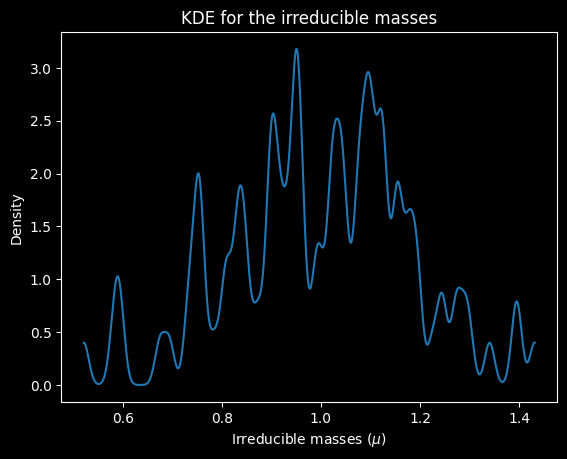

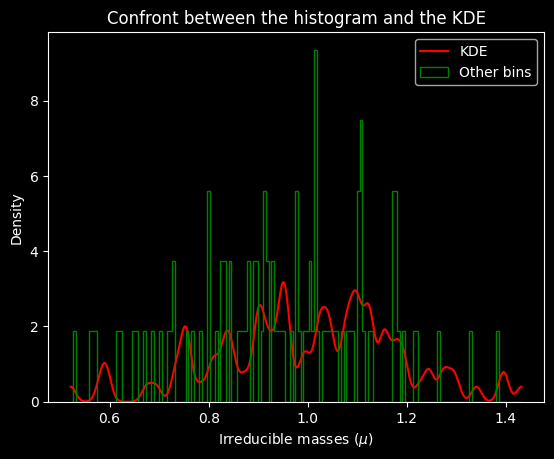

In [49]:
# Now use a KDE to plot the distribution

mass_grid = np.linspace(Og_mass.min(),Og_mass.max(),1000)
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"): #stolen function from the lecture notes
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(mass_grid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

#first try with a gaussian kernell
Gauss_mass = kde_sklearn(Og_mass,bandwidth=0.01,kernel="gaussian") #bandwidth adjousted "ad occhio"
plt.plot(mass_grid,Gauss_mass) 
plt.title('KDE for the irreducible masses')
plt.xlabel(r'Irreducible masses $(\mu)$')
plt.ylabel('Density')
plt.show()

#confronting cause why not 
plt.plot(mass_grid,Gauss_mass, color="#FF0000", label='KDE') 
plt.hist(Irr_mass, bins=binned_2, density=True, histtype='step', label=r'Other bins', color='green')
plt.title('Confront between the histogram and the KDE')
plt.xlabel(r'Irreducible masses $(\mu)$')
plt.ylabel('Density')
plt.legend()
plt.show()